# 01 — EDA
Class distribution + sample grid for EuroSAT. Confirms class balance before training.

In [8]:
import sys, os
sys.path.append(os.path.abspath('..'))
import yaml, matplotlib.pyplot as plt
from collections import Counter
from src.data.datasets import EuroSATDataset
from src.data.transforms import get_eval_transform

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

ds = EuroSATDataset(cfg['paths']['data_raw'], transform=get_eval_transform(cfg['data']['image_size']))
print('Total images:', len(ds))
print('Classes:', ds.classes)


Total images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


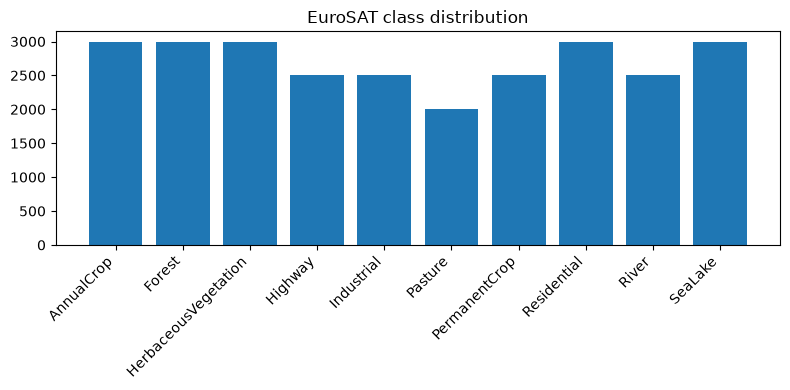

In [9]:
# Class distribution
labels = [ds.base[i][1] for i in range(len(ds))]
counts = Counter(labels)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar([ds.classes[k] for k in counts.keys()], counts.values())
plt.xticks(rotation=45, ha='right')
plt.title('EuroSAT class distribution')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14316294..1.187773].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25926882..1.2905214].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03664702..1.3333333].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13083315..1.5388304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13083315..1.0422125].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3020807..0.45180833].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25

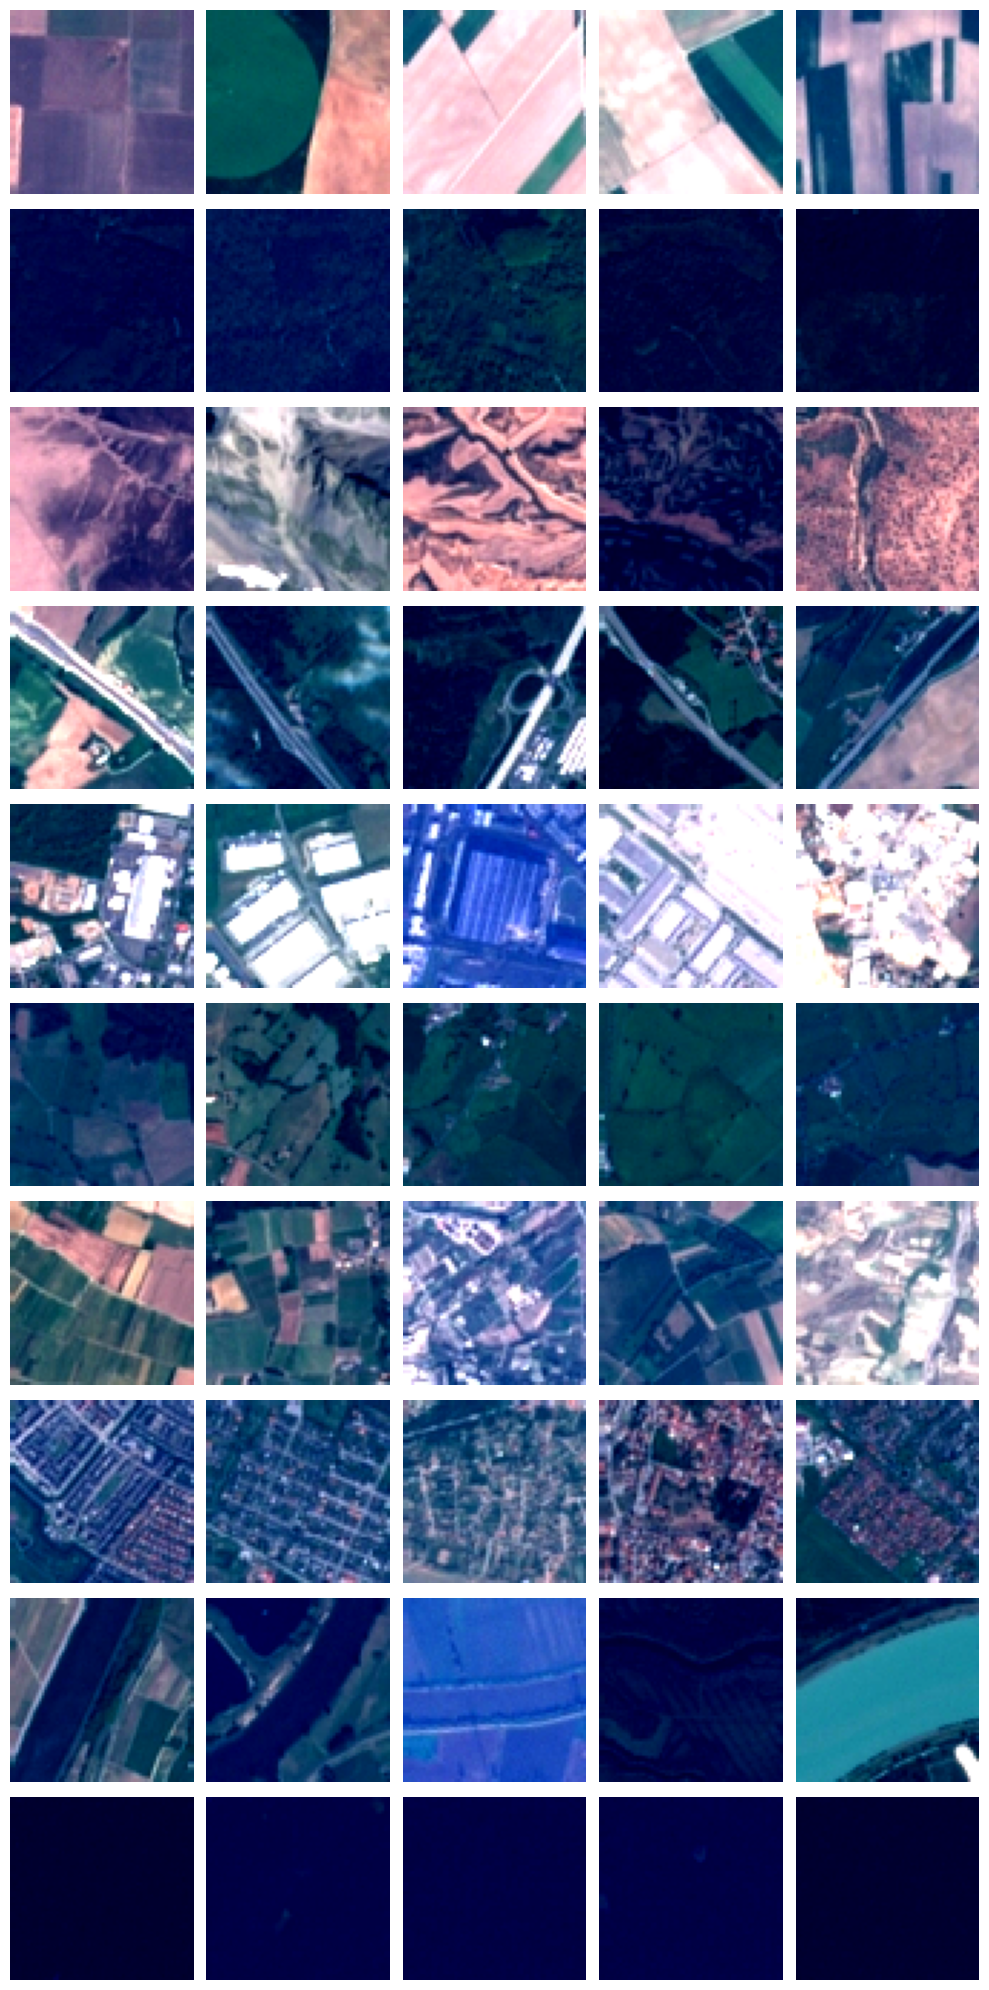

In [10]:
# 5 sample images per class
import random
fig, axes = plt.subplots(len(ds.classes), 5, figsize=(10, 2*len(ds.classes)))
by_class = {c: [] for c in range(len(ds.classes))}
for i, lbl in enumerate(labels):
    if len(by_class[lbl]) < 5:
        by_class[lbl].append(i)

for row, cls_idx in enumerate(range(len(ds.classes))):
    for col, idx in enumerate(by_class[cls_idx]):
        img, _, _ = ds[idx]
        axes[row, col].imshow(img.permute(1,2,0).numpy() * 0.5 + 0.5)  # rough denorm for display
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(ds.classes[cls_idx], rotation=0, labelpad=40)
plt.tight_layout()
plt.savefig('../outputs/figures/sample_grid.png', dpi=150)
plt.show()
